# Growing Ternary Tree Mappings

Ternary trees are one of the most used classes of Fermion encodings, which includes the JordanWigner, BravyiKitaev, Parity and JKMN encodings.

You can create ones of these common ternary trees easily with built-in functions.

If you want a non-standard tree encoding it's easy to build these yourself.

In [1]:
from ferrmion import TernaryTree
from ferrmion.visualise import draw_tt

## Standard Encodings

Ferrmion inbuild functions for the common encodings
- `JordanWigner()` or `JW()`
- `BravyiKitaev()` or `BK()`
- `ParityEncoding()`
- `JKMN()`

The most simple, and common is JordanWigner

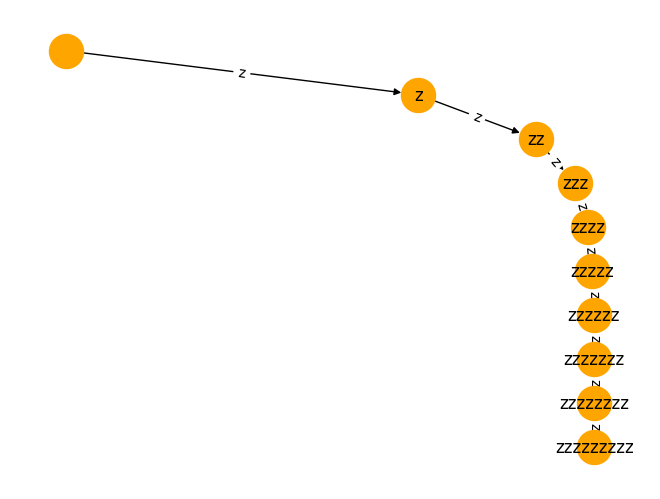

In [2]:
from ferrmion.encode import  JordanWigner
jw = JordanWigner(10)
draw_tt(jw)

### Converting Trees

Given a tree, we can easily convert it to one of the standard encodings.

We want an interesting example of how to grow a tree ourselves, so let's look at Bravyi-Kitaev.

We'll first make one by converting our JordanWigner tree above (of course we could just import and call the fuction like we did above.)

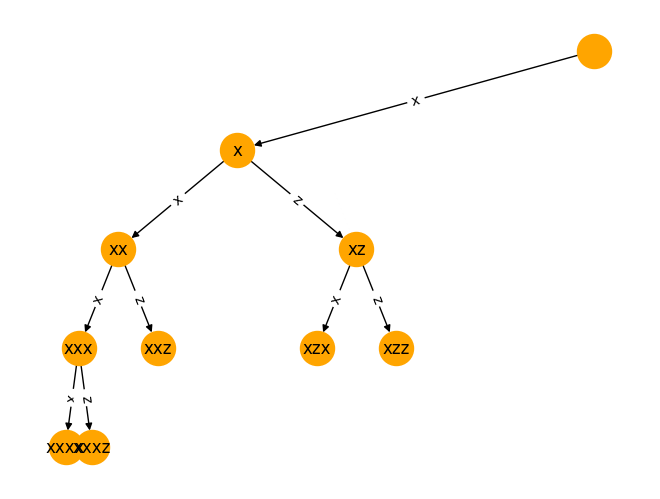

In [10]:
bk = jw.BravyiKitaev()
draw_tt(bk)

## Custom Encodings

Several methods, such as the Bonsai Algorithm and HATT, require building ternary trees on the fly.

`ferrmion` allows you to do this by adding branches.
Let's see how to do this by recreating the BravyiKitaev encoding above.

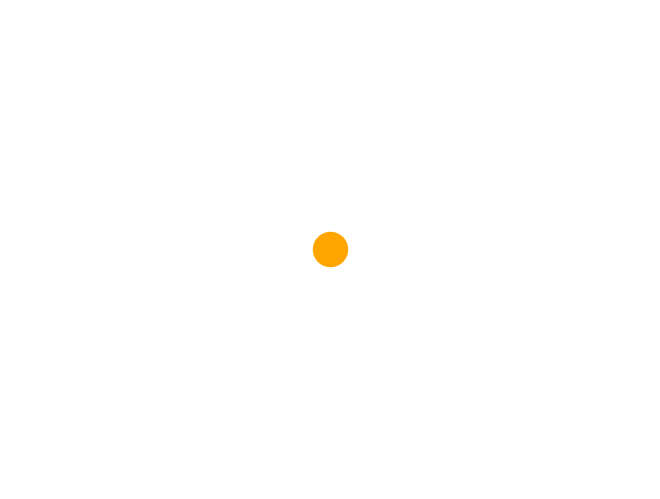

In [4]:
mytt = TernaryTree(n_modes=10)
draw_tt(mytt)

First lets add the left most branch. We can do this by adding a node at `xxxx`. 

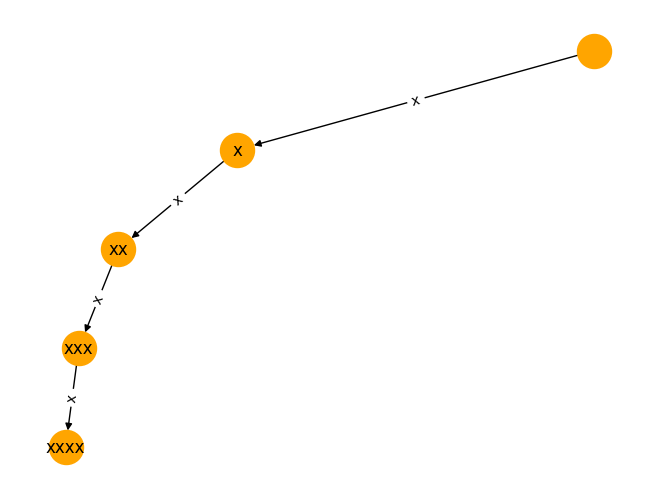

In [5]:
mytt.add_node("xxxx")
draw_tt(mytt)

Because no nodes existed in the path to `xxxx` these were created too!

If we wanted to add the node at `xxz`, then all the nodes to this path exist already.

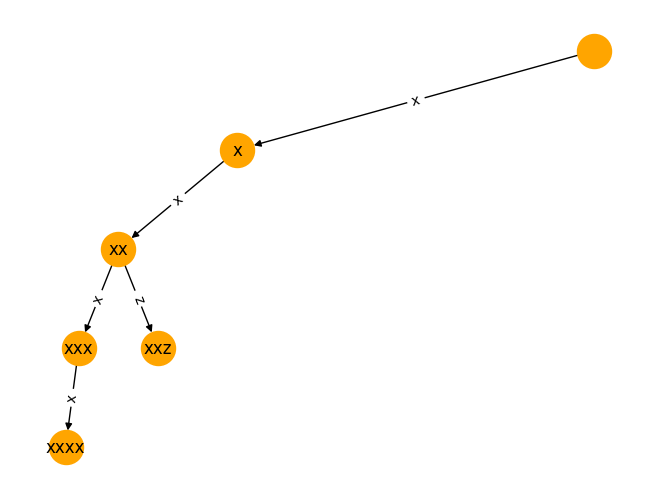

In [6]:
mytt.add_node("xxz")
draw_tt(mytt)

Let's finish growing the BK tree above.

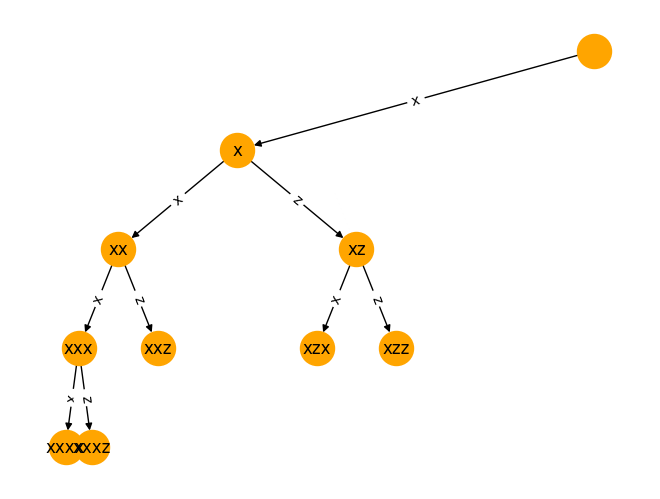

In [7]:
mytt.add_node("xxxz")
mytt.add_node("xzx")
mytt.add_node("xzz")
draw_tt(mytt)

### Enumeration Schemes

Finally, we need to add an enumeration scheme to our tree, this is just a mapping which tells us which nodes correspond to which fermionic mode and qubit.

$$path\to(mode, qubit)$$

We need this information because the encoding builds up a set of Pauli-strings, one for each fermionic mode, by tracing a path from the root to the node, adding an operator to each node's qubit as we pass.

Once we've built a tree, we can use its default enumeration scheme.

In [24]:
mytt.enumeration_scheme=mytt.default_enumeration_scheme()

mytt.enumeration_scheme

{'': (0, 0),
 'x': (1, 1),
 'xx': (2, 2),
 'xz': (3, 3),
 'xxx': (4, 4),
 'xxz': (5, 5),
 'xzx': (6, 6),
 'xzz': (7, 7),
 'xxxx': (8, 8),
 'xxxz': (9, 9)}

We could manually tweak this by updating the values.

In [26]:
mytt.enumeration_scheme["x"] = (1,2)
mytt.enumeration_scheme["xx"] = (2,1)
mytt.enumeration_scheme

{'': (0, 0),
 'x': (1, 2),
 'xx': (2, 1),
 'xz': (3, 3),
 'xxx': (4, 4),
 'xxz': (5, 5),
 'xzx': (6, 6),
 'xzz': (7, 7),
 'xxxx': (8, 8),
 'xxxz': (9, 9)}

If you want to know more about why this is important, see the notebook on [Optimising for Pauli-weight](https://ferrmion.readthedocs.io/en/latest/notebooks/pauli_weight.html) or the [Retuced Entanglement Ternary Tree](https://ferrmion.readthedocs.io/en/latest/notebooks/rett.html).